In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
traffic_stop_df = pd.read_csv("../data/traffic_stop_v1.csv")
driver_vehicle_df = pd.read_csv("../data/driver_vehicle_v1.csv")
violation_charge_df = pd.read_csv("../data/violation_charge_v1.csv")
incident_safety_df = pd.read_csv("../data/incident_safety_v1.csv")
search_enforcement_df = pd.read_csv("../data/search_enforcement_v1.csv")

In [4]:
# ============================================================
# DATASET OVERVIEW
# ============================================================

dfs = {
    'traffic_stop_df'      : traffic_stop_df,
    'driver_vehicle_df'    : driver_vehicle_df,
    'violation_charge_df'  : violation_charge_df,
    'incident_safety_df'   : incident_safety_df,
    'search_enforcement_df': search_enforcement_df,
}

for name, df in dfs.items():
    print(f"\n{name}")
    print(f"  Rows:    {df.shape[0]:,}")
    print(f"  Columns: {df.shape[1]:,}")
    print(f"  Columns: {list(df.columns)}")


traffic_stop_df
  Rows:    568,317
  Columns: 12
  Columns: ['stop_id', 'seq_id', 'stop_timestamp', 'sub_agency', 'district_number', 'location_clean', 'road_1', 'road_2', 'loc_type', 'is_landmark', 'latitude', 'longitude']

driver_vehicle_df
  Rows:    568,317
  Columns: 18
  Columns: ['driver_id', 'stop_id', 'race', 'gender', 'driver_city', 'driver_state', 'dl_state', 'commercial_license', 'hazmat', 'commercial_vehicle', 'alcohol', 'work_zone', 'vehicle_code', 'vehicle_category', 'year', 'make', 'model', 'color']

violation_charge_df
  Rows:    1,046,801
  Columns: 8
  Columns: ['charge_id', 'stop_id', 'description', 'violation_type', 'violation_category', 'charge', 'article', 'search_arrest_reason']

incident_safety_df
  Rows:    568,317
  Columns: 8
  Columns: ['incident_id', 'stop_id', 'accident', 'belts', 'personal_injury', 'property_damage', 'fatal', 'contributed_to_accident']

search_enforcement_df
  Rows:    1,048,575
  Columns: 10
  Columns: ['stop_id', 'driver_id', 'search_c

In [5]:
# Check incident_safety_df
print(f"Unique stop_ids in incident_safety_df: {incident_safety_df['stop_id'].nunique():,}")
print(f"Unique stop_ids in traffic_stop_df:    {traffic_stop_df['stop_id'].nunique():,}")

# Check search_enforcement_df  
print(f"\nUnique stop_ids in search_enforcement_df: {search_enforcement_df['stop_id'].nunique():,}")

# Check violation_charge_df
print(f"\nUnique stop_ids in violation_charge_df: {violation_charge_df['stop_id'].nunique():,}")
print(f"Total charges: {violation_charge_df.shape[0]:,}")

Unique stop_ids in incident_safety_df: 568,317
Unique stop_ids in traffic_stop_df:    568,317

Unique stop_ids in search_enforcement_df: 568,317

Unique stop_ids in violation_charge_df: 568,317
Total charges: 1,046,801


## 1. Temporal Analysis

In [6]:
# ============================================================
# 1. TEMPORAL ANALYSIS
# ============================================================

# Ensure datetime
traffic_stop_df['stop_timestamp'] = pd.to_datetime(traffic_stop_df['stop_timestamp'])

# Extract time components
traffic_stop_df['year']       = traffic_stop_df['stop_timestamp'].dt.year
traffic_stop_df['month']      = traffic_stop_df['stop_timestamp'].dt.month
traffic_stop_df['day_of_week']= traffic_stop_df['stop_timestamp'].dt.day_name()
traffic_stop_df['hour']       = traffic_stop_df['stop_timestamp'].dt.hour

# Overview
print(f"Date range: {traffic_stop_df['stop_timestamp'].min()} → {traffic_stop_df['stop_timestamp'].max()}")
print(f"\nStops by year:")
print(traffic_stop_df['year'].value_counts().sort_index())
print(f"\nStops by day of week:")
print(traffic_stop_df['day_of_week'].value_counts())
print(f"\nStops by hour:")
print(traffic_stop_df['hour'].value_counts().sort_index())

Date range: 2012-01-01 00:43:00 → 2025-12-11 22:31:00

Stops by year:
year
2012    58526
2013    67355
2014    71617
2015    65158
2016    60195
2017    48851
2018    49017
2019    41176
2020    16152
2021    17812
2022    15952
2023    31179
2024    24162
2025     1165
Name: count, dtype: int64

Stops by day of week:
day_of_week
Tuesday      95613
Wednesday    93592
Thursday     90962
Friday       87273
Monday       81811
Saturday     60346
Sunday       58720
Name: count, dtype: int64

Stops by hour:
hour
0     19596
1     16043
2     11965
3      7447
4      4763
5      5127
6     14725
7     36232
8     47378
9     38668
10    36279
11    30363
12    27691
13    27654
14    28450
15    25363
16    31822
17    30852
18    21764
19    16356
20    15784
21    20270
22    27301
23    26424
Name: count, dtype: int64


- Year Trends:
```a
Peak years:    2014 (71,617) → 2013 (67,355) → 2012 (58,526)
Steady decline: 2015 → 2020
COVID drop:    2020 (16,152) → lowest point
Recovery:      2021-2023 partial recovery
2025:          1,165 → incomplete year (only Jan data)

- Day of Week:
```b
Busiest:   Tuesday (95,613)
Quietest:  Sunday (58,720)
Weekdays dominate — makes sense, more traffic/patrols
Weekend drops significantly

- Hour of Day:
```c
Morning peak:  8am  (47,378) → commute hours
Evening peak:  4pm  (31,822) → commute hours
Late night:    midnight (19,596) → still significant
Dead zone:     4am  (4,763) → quietest

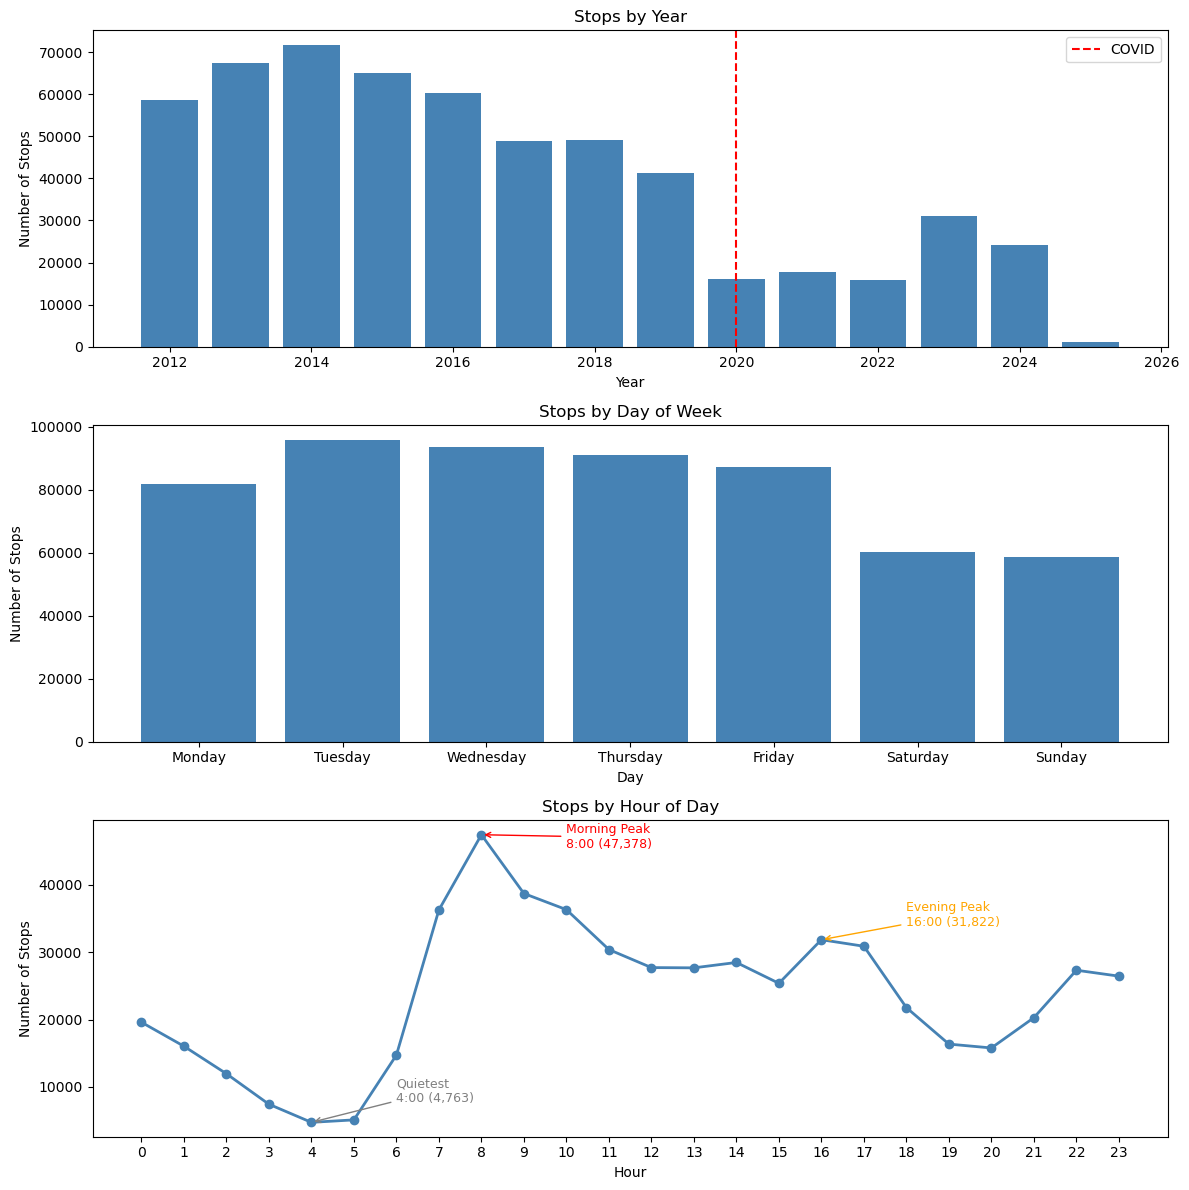

Saved: temporal_analysis.png


In [8]:
fig, axes = plt.subplots(3, 1, figsize=(12, 12))


# 1. Stops by Year
year_counts = traffic_stop_df['year'].value_counts().sort_index()
axes[0].bar(year_counts.index, year_counts.values, color='steelblue')
axes[0].set_title('Stops by Year')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Number of Stops')
axes[0].axvline(x=2020, color='red', linestyle='--', label='COVID')
axes[0].legend()

# 2. Stops by Day of Week
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_counts = traffic_stop_df['day_of_week'].value_counts().reindex(day_order)
axes[1].bar(day_counts.index, day_counts.values, color='steelblue')
axes[1].set_title('Stops by Day of Week')
axes[1].set_xlabel('Day')
axes[1].set_ylabel('Number of Stops')

# 3. Stops by Hour
hour_counts = traffic_stop_df['hour'].value_counts().sort_index()
axes[2].plot(hour_counts.index, hour_counts.values, 
             color='steelblue', marker='o', linewidth=2)
axes[2].set_title('Stops by Hour of Day')
axes[2].set_xlabel('Hour')
axes[2].set_ylabel('Number of Stops')
axes[2].set_xticks(range(0, 24))

# Annotate peaks
peak_hour = hour_counts.idxmax()
peak_val  = hour_counts.max()
axes[2].annotate(
    f'Morning Peak\n{peak_hour}:00 ({peak_val:,})',
    xy=(peak_hour, peak_val),
    xytext=(peak_hour + 2, peak_val - 2000),
    arrowprops=dict(arrowstyle='->', color='red'),
    color='red', fontsize=9
)

# Evening peak (4pm = 16)
eve_hour = 16
eve_val  = hour_counts[eve_hour]
axes[2].annotate(
    f'Evening Peak\n{eve_hour}:00 ({eve_val:,})',
    xy=(eve_hour, eve_val),
    xytext=(eve_hour + 2, eve_val + 2000),
    arrowprops=dict(arrowstyle='->', color='orange'),
    color='orange', fontsize=9
)

# Dead zone (4am = 4)
dead_hour = hour_counts.idxmin()
dead_val  = hour_counts.min()
axes[2].annotate(
    f'Quietest\n{dead_hour}:00 ({dead_val:,})',
    xy=(dead_hour, dead_val),
    xytext=(dead_hour + 2, dead_val + 3000),
    arrowprops=dict(arrowstyle='->', color='gray'),
    color='gray', fontsize=9
)

plt.tight_layout()
plt.savefig('../images/temporal_analysis.png', dpi=100, bbox_inches='tight')
plt.show()
print("Saved: temporal_analysis.png")

## 2. VIOLATION ANALYSIS

In [8]:
# ============================================================
# 2. VIOLATION ANALYSIS
# ============================================================

# Most common violation categories
print("Top violation categories:")
print(violation_charge_df['violation_category'].value_counts())

print("\nViolation type breakdown:")
print(violation_charge_df['violation_type'].value_counts())

# Citation vs Warning by category
print("\nCitation vs Warning by category:")
citation_warning = violation_charge_df[
    violation_charge_df['violation_type'].isin(['CITATION', 'WARNING'])
].groupby(['violation_category', 'violation_type']).size().unstack(fill_value=0)
citation_warning['citation_rate'] = (
    citation_warning['CITATION'] / 
    (citation_warning['CITATION'] + citation_warning['WARNING']) * 100
).round(1)
print(citation_warning.sort_values('citation_rate', ascending=False))

Top violation categories:
violation_category
LICENSE          243918
SPEED            210315
PHONE            110871
REGISTRATION      81618
DUI               71167
EQUIPMENT         50788
FRAUD             43205
RECKLESS          38344
LANE              37098
SEATBELT          28778
STOP SIGN         27492
YIELD             23097
INSURANCE         18419
RED LIGHT         17783
HIT AND RUN       12053
IMPROPER TURN     11714
PARKING            6829
OTHER              5642
FOLLOWING          4863
MEDICAL            2807
Name: count, dtype: int64

Violation type breakdown:
violation_type
CITATION    847460
WARNING     189449
ESERO         9803
SERO            89
Name: count, dtype: int64

Citation vs Warning by category:
violation_type      CITATION  WARNING  citation_rate
violation_category                                  
DUI                    71099       68           99.9
HIT AND RUN            11938      115           99.0
LICENSE               230752    13166           94.6
RECKLE

- Top Violations:

```LICENSE     243,918  → most common by far
SPEED       210,315  → second most common
PHONE       110,871  → third — distracted driving
REGISTRATION 81,618  → fourth
DUI          71,167  → fifth — serious
```

- Citation Rate insights:

```a
Strictest (99%+ citation):
DUI         99.9%  → almost always cited
HIT AND RUN 99.0%  → always cited, serious offense

Most warnings given:
EQUIPMENT   65.2%  → officers give warnings for fix-it tickets
PHONE       66.5%  → surprisingly lenient
SPEED       71.6%  → nearly 1 in 3 get warnings

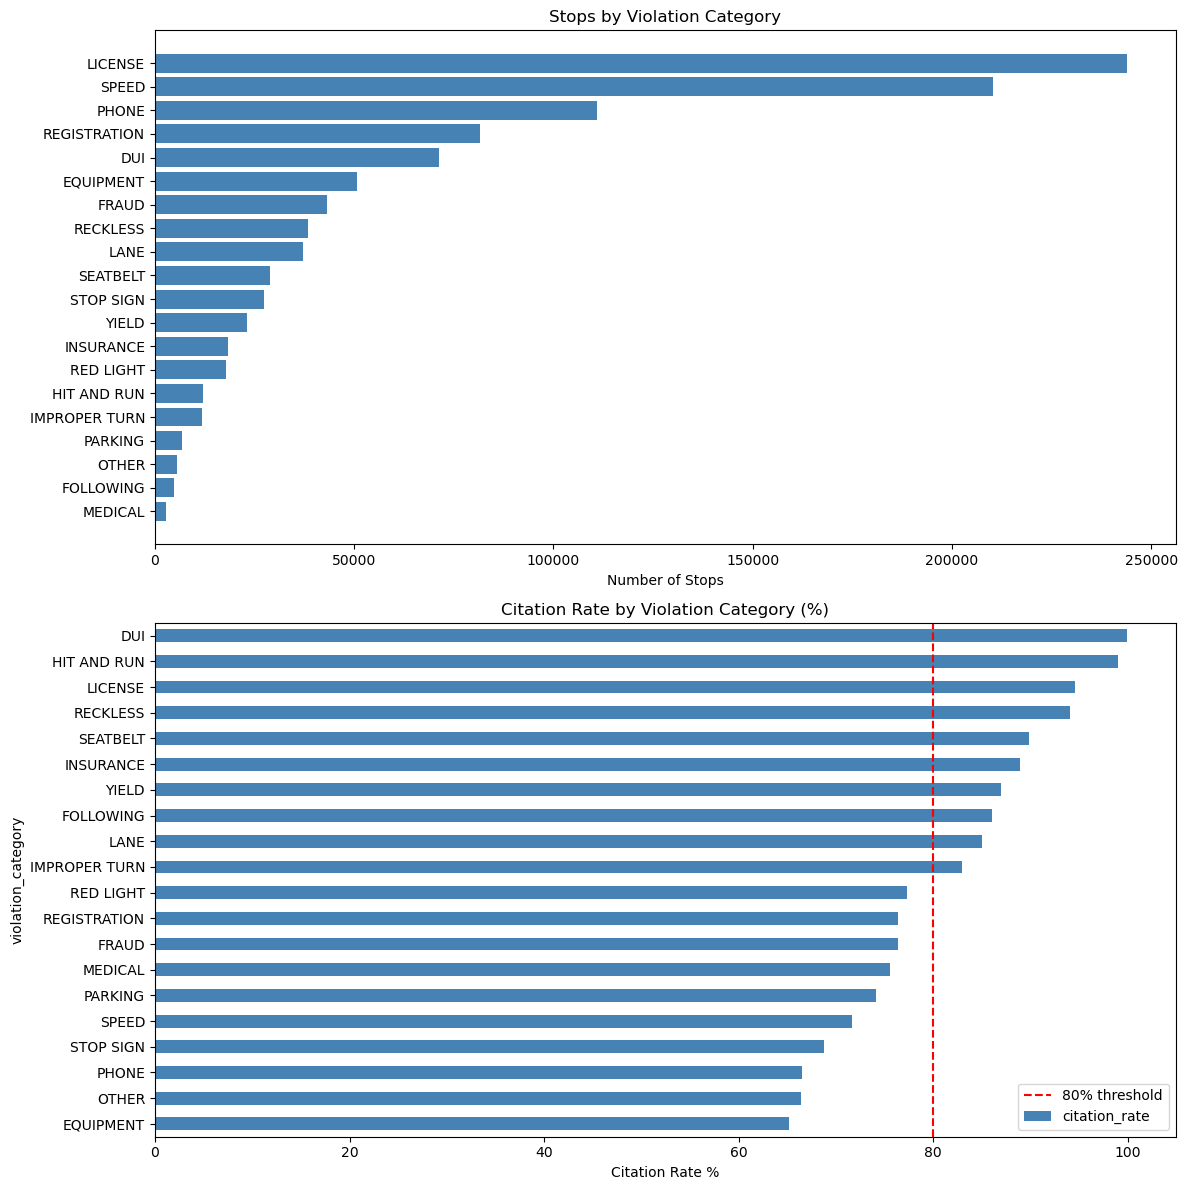

In [ ]:
# ============================================================
# VIOLATION ANALYSIS - QUICK PLOTS
# ============================================================

fig, axes = plt.subplots(2, 1, figsize=(12, 12))

# 1. Top violation categories
top_violations = violation_charge_df['violation_category'].value_counts()
axes[0].barh(top_violations.index[::-1], top_violations.values[::-1], color='steelblue')
axes[0].set_title('Stops by Violation Category')
axes[0].set_xlabel('Number of Stops')

# 2. Citation rate by category
citation_warning['citation_rate'].sort_values().plot(
    kind='barh', ax=axes[1], color='steelblue'
)
axes[1].set_title('Citation Rate by Violation Category (%)')
axes[1].set_xlabel('Citation Rate %')
axes[1].axvline(x=80, color='red', linestyle='--', label='80% threshold')
axes[1].legend()

plt.tight_layout()
plt.savefig('../images/violation_analysis.png', dpi=100, bbox_inches='tight')
plt.show()

## 3. GEOGRAPHIC ANALYSIS

In [10]:
# ============================================================
# 3. GEOGRAPHIC ANALYSIS
# ============================================================

# Stops by district
print("Stops by district:")
print(traffic_stop_df['district_number'].value_counts().sort_index())

# Stops by sub_agency
print("\nStops by sub_agency:")
print(traffic_stop_df['sub_agency'].value_counts().head(10))

# Location type breakdown
print("\nLocation type breakdown:")
print(traffic_stop_df['loc_type'].value_counts())

# Top hotspot locations
print("\nTop 20 hotspot locations:")
print(traffic_stop_df['location_clean'].value_counts().head(20))

Stops by district:
district_number
1.0     70103
2.0    104907
3.0     93740
4.0    101866
5.0     81143
6.0     64099
Name: count, dtype: int64

Stops by sub_agency:
sub_agency
2nd District, Bethesda                             104907
4th District, Wheaton                              101866
3rd District, Silver Spring                         93740
5th District, Germantown                            81143
1st District, Rockville                             70103
6th District, Gaithersburg / Montgomery Village     64099
Headquarters And Special Operations                 52459
Name: count, dtype: int64

Location type breakdown:
loc_type
intersection    501338
address          47931
single_road      19048
Name: count, dtype: int64

Top 20 hotspot locations:
location_clean
IS 370/IS 270                            1703
10901 WESTLAKE DRIVE                     1425
RT 28/BLACKBERRY DR                      1239
GEORGIA AVE/COLESVILLE RD                1078
RIVER RD/GOLDSBORO RD             

- District breakdown:

```a
District 2 (Bethesda):      104,907  → busiest
District 4 (Wheaton):       101,866  → second
District 3 (Silver Spring):  93,740  → third
District 5 (Germantown):     81,143
District 1 (Rockville):      70,103
District 6 (Gaithersburg):   64,099  → quietest

- Location types:

```b
Intersection   501,338  (88.2%)  → most stops at intersections
Address         47,931   (8.4%)  → specific addresses
Single road     19,048   (3.4%)  → highway/road stops

- Top hotspots:

```a
IS 370/IS 270        1,703  → highway interchange
10901 WESTLAKE DR    1,425  → specific address
RT 28/BLACKBERRY DR  1,239  → intersection

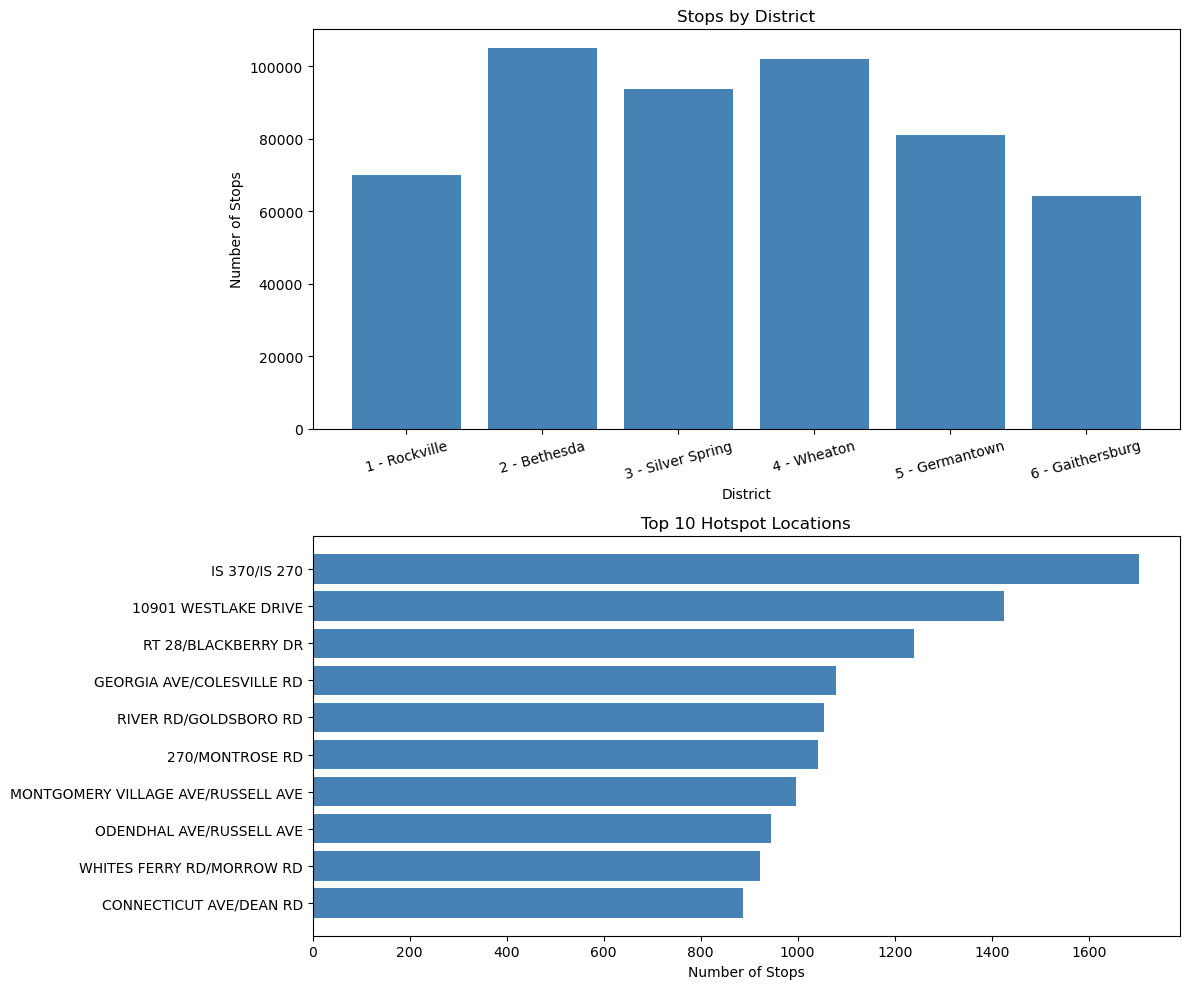

In [ ]:
# ============================================================
# GEOGRAPHIC ANALYSIS - QUICK PLOTS
# ============================================================

fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# 1. Stops by district
district_counts = traffic_stop_df['district_number'].value_counts().sort_index()
district_labels = [
    '1 - Rockville', '2 - Bethesda', '3 - Silver Spring',
    '4 - Wheaton', '5 - Germantown', '6 - Gaithersburg'
]
axes[0].bar(district_labels, district_counts.values, color='steelblue')
axes[0].set_title('Stops by District')
axes[0].set_xlabel('District')
axes[0].set_ylabel('Number of Stops')
axes[0].tick_params(axis='x', rotation=15)

# 2. Top 10 hotspot locations
top_locations = traffic_stop_df['location_clean'].value_counts().head(10)
axes[1].barh(top_locations.index[::-1], top_locations.values[::-1], color='steelblue')
axes[1].set_title('Top 10 Hotspot Locations')
axes[1].set_xlabel('Number of Stops')

plt.tight_layout()
plt.savefig('../images/geographic_analysis.png', dpi=100, bbox_inches='tight')
plt.show()

## 4. VEHICLE ANALYSIS

In [12]:
# ============================================================
# 4. VEHICLE ANALYSIS
# ============================================================

# Top makes
print("Top 15 makes:")
print(driver_vehicle_df['make'].value_counts().head(15))

# Top models
print("\nTop 15 models:")
print(driver_vehicle_df['model'].value_counts().head(15))

# Vehicle year distribution
print("\nVehicle year distribution:")
print(driver_vehicle_df['year'].value_counts().sort_index().tail(20))

# Top colors
print("\nTop colors:")
print(driver_vehicle_df['color'].value_counts().head(10))

# Vehicle category
print("\nVehicle category:")
print(driver_vehicle_df['vehicle_category'].value_counts())

Top 15 makes:
make
TOYOTA           101559
HONDA             83965
FORD              52075
NISSAN            40485
CHEVROLET         40246
HYUNDAI           20328
ACURA             17264
DODGE             17228
BMW               16835
MERCEDES-BENZ     16832
LEXUS             14509
VOLKSWAGEN        14158
JEEP              13249
MAZDA             11396
UNKNOWN           10962
Name: count, dtype: int64

Top 15 models:
model
SEDAN            100032
TRUCK             48172
ACCORD            19548
SUV               19273
CAMRY             19036
CIVIC             18613
COROLLA           16720
VAN               15692
UNKNOWN           12841
ALTIMA             9365
CRV                7303
RAV4               6716
STATION WAGON      4667
SONATA             4444
F150               4367
Name: count, dtype: int64

Vehicle year distribution:
year
2006.0    30367
2007.0    31552
2008.0    29306
2009.0    22548
2010.0    27795
2011.0    29948
2012.0    32571
2013.0    31810
2014.0    27588
2015.0    

- Top Makes:

```a
TOYOTA    101,559  → most stopped by far
HONDA      83,965  → second
FORD       52,075  → third

- Top Models:

```a
SEDAN     100,032  → body style dominates
TRUCK      48,172  → second
ACCORD     19,548  → top real model name


- Vehicle Years:

```a
Peak:  2006-2013  → older vehicles stopped more
Recent 2020+      → fewer stops (newer cars)


- Top Colors:

```a
BLACK     117,947  → most stopped
SILVER     95,184
WHITE      92,901

- Vehicle Category:

```a
AUTOMOBILE        473,870  (83.4%)
LIGHT DUTY TRUCK   43,225   (7.6%)

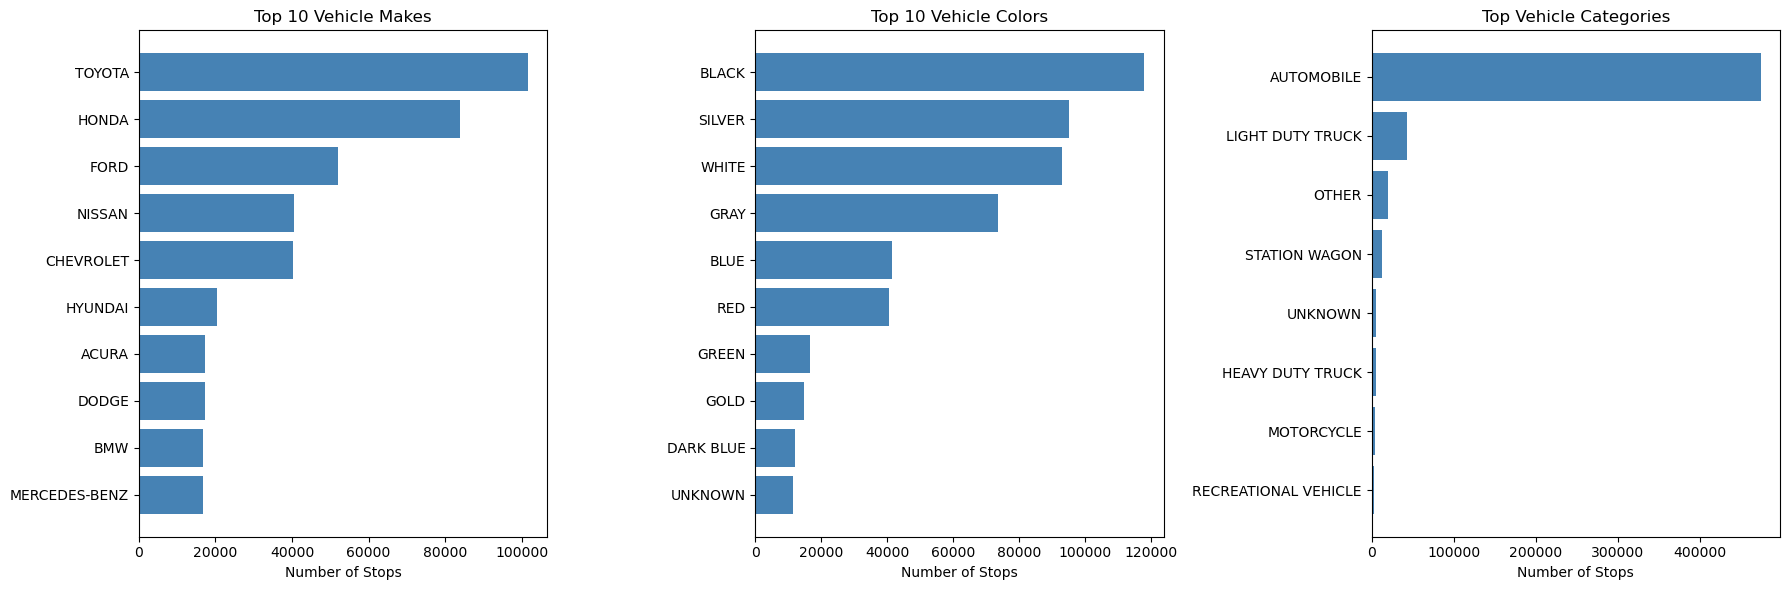

In [ ]:
# ============================================================
# VEHICLE ANALYSIS - CHART 1: Make, Color, Category
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 1. Top 10 makes
top_makes = driver_vehicle_df['make'].value_counts().head(10)
axes[0].barh(top_makes.index[::-1], top_makes.values[::-1], color='steelblue')
axes[0].set_title('Top 10 Vehicle Makes')
axes[0].set_xlabel('Number of Stops')

# 2. Top 10 colors
top_colors = driver_vehicle_df['color'].value_counts().head(10)
axes[1].barh(top_colors.index[::-1], top_colors.values[::-1], color='steelblue')
axes[1].set_title('Top 10 Vehicle Colors')
axes[1].set_xlabel('Number of Stops')

# 3. Vehicle category
top_cats = driver_vehicle_df['vehicle_category'].value_counts().head(8)
axes[2].barh(top_cats.index[::-1], top_cats.values[::-1], color='steelblue')
axes[2].set_title('Top Vehicle Categories')
axes[2].set_xlabel('Number of Stops')

plt.tight_layout()
plt.savefig('../images/vehicle_analysis_1.png', dpi=100, bbox_inches='tight')
plt.show()


In [14]:
# Calculate vehicle age at time of stop
traffic_stop_df['stop_year'] = traffic_stop_df['stop_timestamp'].dt.year

# Merge with driver_vehicle_df
vehicle_age_df = driver_vehicle_df[['stop_id', 'year']].merge(
    traffic_stop_df[['stop_id', 'stop_year']], on='stop_id'
)

# Calculate age
vehicle_age_df['vehicle_age'] = vehicle_age_df['stop_year'] - vehicle_age_df['year']

# Remove unrealistic ages
vehicle_age_df = vehicle_age_df[
    (vehicle_age_df['vehicle_age'] >= 0) & 
    (vehicle_age_df['vehicle_age'] <= 30)
]

print("Vehicle age at time of stop:")
print(vehicle_age_df['vehicle_age'].describe())
print(f"\nMost common ages:")
print(vehicle_age_df['vehicle_age'].value_counts().sort_index().head(20))

Vehicle age at time of stop:
count    559786.000000
mean          8.277803
std           5.685538
min           0.000000
25%           4.000000
50%           8.000000
75%          12.000000
max          30.000000
Name: vehicle_age, dtype: float64

Most common ages:
vehicle_age
0.0     25931
1.0     37850
2.0     36417
3.0     36439
4.0     36630
5.0     35417
6.0     34533
7.0     33502
8.0     32916
9.0     32176
10.0    30575
11.0    29111
12.0    27138
13.0    24759
14.0    21729
15.0    18463
16.0    15659
17.0    12727
18.0     9958
19.0     7749
Name: count, dtype: int64


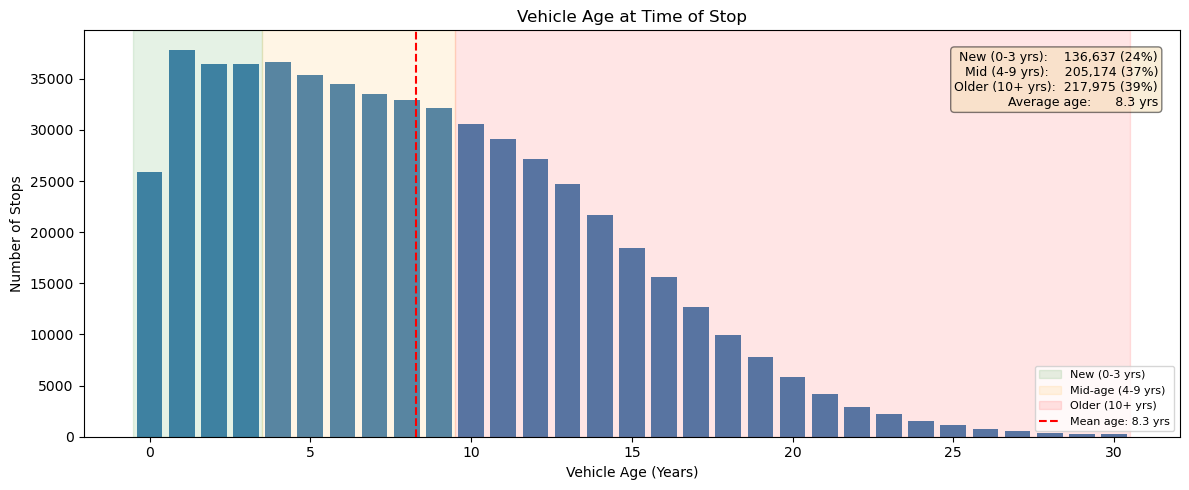

In [ ]:

# ============================================================
# VEHICLE ANALYSIS - CHART 2: Vehicle Age
# ============================================================

fig, ax = plt.subplots(figsize=(12, 5))

age_counts = vehicle_age_df['vehicle_age'].value_counts().sort_index()
ax.bar(age_counts.index, age_counts.values, color='steelblue')
ax.set_title('Vehicle Age at Time of Stop')
ax.set_xlabel('Vehicle Age (Years)')
ax.set_ylabel('Number of Stops')

# Shade age groups
ax.axvspan(-0.5, 3.5,  alpha=0.1, color='green',  label='New (0-3 yrs)')
ax.axvspan(3.5,  9.5,  alpha=0.1, color='orange', label='Mid-age (4-9 yrs)')
ax.axvspan(9.5,  30.5, alpha=0.1, color='red',    label='Older (10+ yrs)')

# Summary text box
new   = age_counts[age_counts.index <= 3].sum()
mid   = age_counts[(age_counts.index > 3) & (age_counts.index <= 9)].sum()
old   = age_counts[age_counts.index > 9].sum()
total = new + mid + old

ax.text(
    0.98, 0.95,
    f'New (0-3 yrs):    {new:,} ({new/total*100:.0f}%)\n'
    f'Mid (4-9 yrs):    {mid:,} ({mid/total*100:.0f}%)\n'
    f'Older (10+ yrs):  {old:,} ({old/total*100:.0f}%)\n'
    f'Average age:      {vehicle_age_df["vehicle_age"].mean():.1f} yrs',
    transform=ax.transAxes,
    verticalalignment='top',
    horizontalalignment='right',
    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5),
    fontsize=9
)

ax.axvline(x=vehicle_age_df['vehicle_age'].mean(),
           color='red', linestyle='--',
           label=f'Mean age: {vehicle_age_df["vehicle_age"].mean():.1f} yrs')
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('../images/vehicle_analysis_2.png', dpi=100, bbox_inches='tight')
plt.show()


## 5. SEARCH ANALYSIS

In [16]:
# ============================================================
# 5. SEARCH ANALYSIS
# ============================================================

# Search rate overall
total_stops = search_enforcement_df['stop_id'].nunique()
searches = (search_enforcement_df['search_conducted'] == 1).sum()
print(f"Total stops:    {total_stops:,}")
print(f"Searches:       {searches:,}")
print(f"Search rate:    {searches/total_stops*100:.1f}%")

# Search reason breakdown (exclude Not Applicable)
print("\nSearch reason breakdown:")
print(search_enforcement_df[
    search_enforcement_df['search_reason'] != 'Not Applicable'
]['search_reason'].value_counts())

# Contraband hit rate
searched = search_enforcement_df[
    search_enforcement_df['search_conducted'] == 1
]
contraband = searched[
    searched['search_disposition'].str.contains('Contraband', na=False)
].shape[0]
print(f"\nContraband hit rate: {contraband/searches*100:.1f}%")

# Search type breakdown
print("\nSearch type breakdown:")
print(search_enforcement_df[
    search_enforcement_df['search_type'] != 'NOT APPLICABLE'
]['search_type'].value_counts())

# Arrest rate
arrests = (search_enforcement_df['search_outcome'] == 'Arrest').sum()
print(f"\nArrest rate:    {arrests/total_stops*100:.1f}%")
print(f"Arrests:        {arrests:,}")

Total stops:    568,317
Searches:       69,983
Search rate:    12.3%

Search reason breakdown:
search_reason
Incident to Arrest       46937
Probable Cause           12853
Consensual                7794
K-9                       1013
Other                      933
Exigent Circumstances      452
Plain View                   1
Name: count, dtype: int64

Contraband hit rate: 36.7%

Search type breakdown:
search_type
BOTH                  52328
PERSON                 9594
PROPERTY               8050
INCIDENT TO ARREST        3
PROBABLE CAUSE            1
Name: count, dtype: int64

Arrest rate:    9.4%
Arrests:        53,537


```a
Search rate:         12.3%  → 1 in 8 stops leads to search
Contraband hit rate: 36.7%  → 1 in 3 searches finds contraband
Arrest rate:          9.4%  → 1 in 10 stops leads to arrest

- Search reasons:

```a
Incident to Arrest   46,937  (67.1%)  → most common
Probable Cause       12,853  (18.4%)
Consensual            7,794  (11.1%)  → driver agreed
K-9                   1,013   (1.4%)  → drug dog
Exigent Circumstances   452   (0.6%)  → emergency

- Search types:

```a
BOTH      52,328  (74.8%)  → person + vehicle searched
PERSON     9,594  (13.7%)
PROPERTY   8,050  (11.5%)

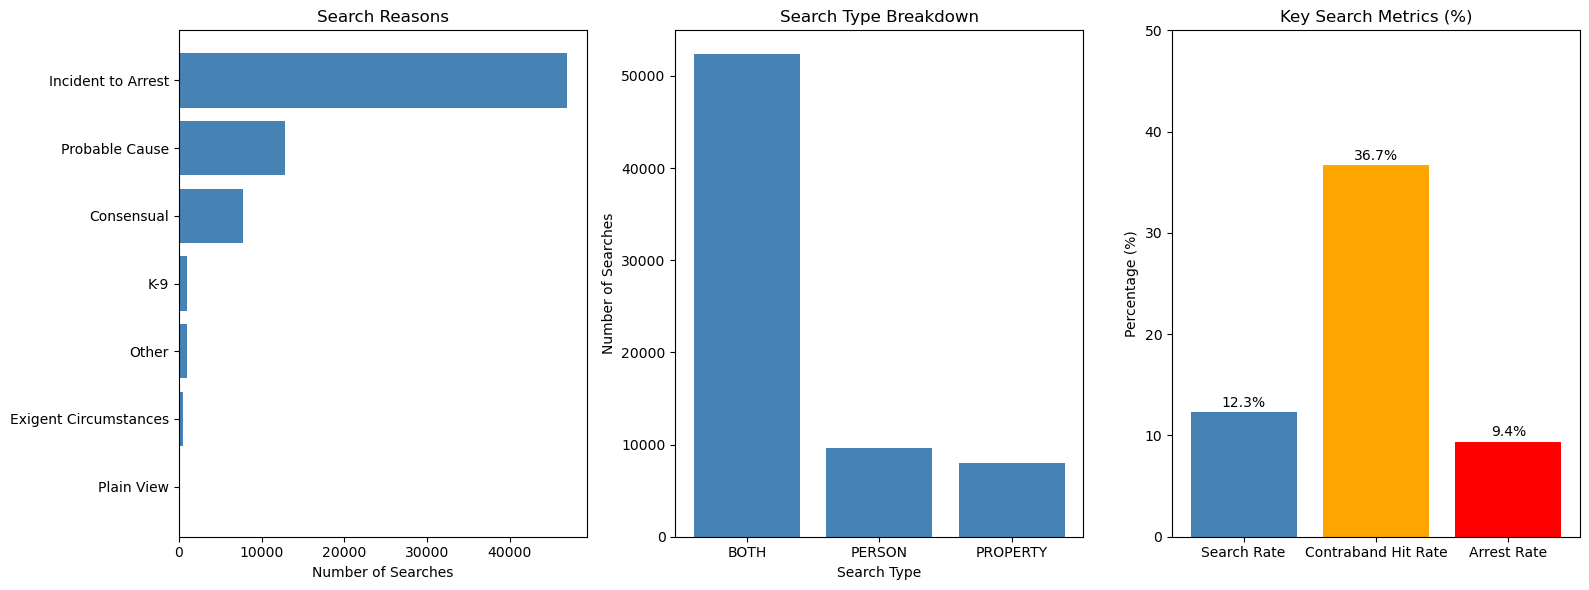

In [ ]:
# ============================================================
# SEARCH ANALYSIS - QUICK PLOTS
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(16, 6))

# 1. Search reason breakdown
search_reasons = search_enforcement_df[
    search_enforcement_df['search_reason'] != 'Not Applicable'
]['search_reason'].value_counts()
axes[0].barh(search_reasons.index[::-1], search_reasons.values[::-1], color='steelblue')
axes[0].set_title('Search Reasons')
axes[0].set_xlabel('Number of Searches')

# 2. Search type breakdown
search_types = search_enforcement_df[
    ~search_enforcement_df['search_type'].isin(['NOT APPLICABLE', 'INCIDENT TO ARREST', 'PROBABLE CAUSE'])
]['search_type'].value_counts()
axes[1].bar(search_types.index, search_types.values, color='steelblue')
axes[1].set_title('Search Type Breakdown')
axes[1].set_xlabel('Search Type')
axes[1].set_ylabel('Number of Searches')

# 3. Key metrics summary
metrics = ['Search Rate', 'Contraband Hit Rate', 'Arrest Rate']
values  = [12.3, 36.7, 9.4]
colors  = ['steelblue', 'orange', 'red']
axes[2].bar(metrics, values, color=colors)
axes[2].set_title('Key Search Metrics (%)')
axes[2].set_ylabel('Percentage (%)')
axes[2].set_ylim(0, 50)
for i, v in enumerate(values):
    axes[2].text(i, v + 0.5, f'{v}%', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('../images/search_analysis.png', dpi=100, bbox_inches='tight')
plt.show()

## 6. DEMOGRAPHIC ANALYSIS

In [18]:
# ============================================================
# 6. DEMOGRAPHIC ANALYSIS
# ============================================================

# Race breakdown
print("Stops by race:")
print(driver_vehicle_df['race'].value_counts())

# Gender breakdown
print("\nStops by gender:")
print(driver_vehicle_df['gender'].value_counts())

# Search rate by race
race_search = search_enforcement_df.merge(
    driver_vehicle_df[['stop_id', 'race']], on='stop_id'
)
print("\nSearch rate by race:")
print(race_search.groupby('race')['search_conducted'].mean().sort_values(ascending=False).round(3) * 100)

# Arrest rate by race
print("\nArrest rate by race:")
arrests_by_race = race_search.groupby('race').agg(
    total=('stop_id', 'count'),
    arrests=('search_outcome', lambda x: (x == 'Arrest').sum())
).reset_index()
arrests_by_race['arrest_rate'] = (arrests_by_race['arrests'] / arrests_by_race['total'] * 100).round(1)
print(arrests_by_race.sort_values('arrest_rate', ascending=False))

Stops by race:
race
WHITE              220031
BLACK              159460
HISPANIC           112302
OTHER               40518
ASIAN               35006
NATIVE AMERICAN      1000
Name: count, dtype: int64

Stops by gender:
gender
M    367583
F    199867
U       867
Name: count, dtype: int64

Search rate by race:
race
HISPANIC           8.8
BLACK              8.1
WHITE              4.9
NATIVE AMERICAN    4.9
ASIAN              3.7
OTHER              2.8
Name: search_conducted, dtype: float64

Arrest rate by race:
              race   total  arrests  arrest_rate
2         HISPANIC  255721    18954          7.4
1            BLACK  329224    18418          5.6
3  NATIVE AMERICAN    1748       76          4.3
5            WHITE  348788    13252          3.8
0            ASIAN   51890     1551          3.0
4            OTHER   61204     1286          2.1


- Stop distribution:

```a
WHITE     220,031  (38.7%)
BLACK     159,460  (28.1%)
HISPANIC  112,302  (19.8%)
OTHER      40,518   (7.1%)
ASIAN      35,006   (6.2%)

- Search rate by race:

```a
HISPANIC    8.8%  → highest search rate
BLACK       8.1%  → second highest
WHITE       4.9%  → nearly half Hispanic rate
ASIAN       3.7%
OTHER       2.8%  → lowest

- Arrest rate by race:

```a
HISPANIC    7.4%  → highest
BLACK       5.6%  → second
WHITE       3.8%  → less than half Hispanic rate
ASIAN       3.0%
OTHER       2.1%  → lowest

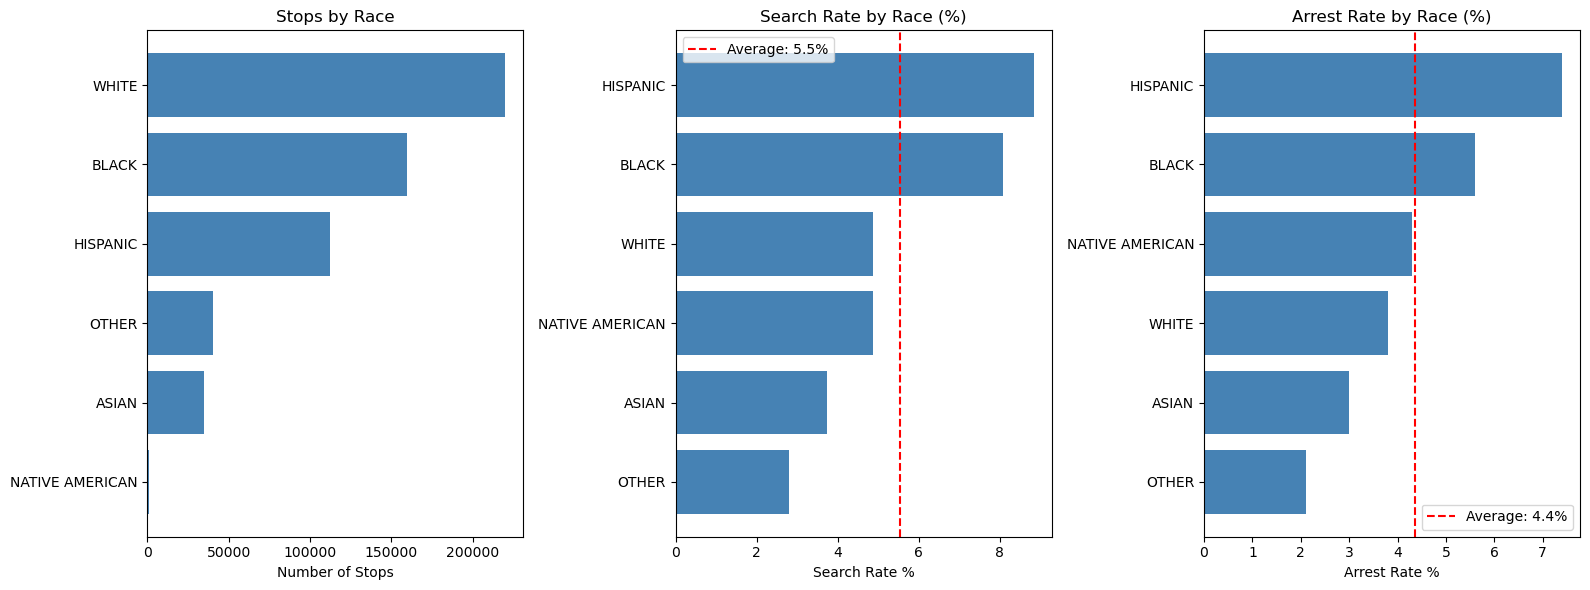

In [ ]:
# ============================================================
# DEMOGRAPHIC ANALYSIS - QUICK PLOTS
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(16, 6))

# 1. Stops by race
race_counts = driver_vehicle_df['race'].value_counts()
axes[0].barh(race_counts.index[::-1], race_counts.values[::-1], color='steelblue')
axes[0].set_title('Stops by Race')
axes[0].set_xlabel('Number of Stops')

# 2. Search rate by race
search_by_race = race_search.groupby('race')['search_conducted'].mean().sort_values() * 100
axes[1].barh(search_by_race.index, search_by_race.values, color='steelblue')
axes[1].set_title('Search Rate by Race (%)')
axes[1].set_xlabel('Search Rate %')
axes[1].axvline(x=search_by_race.mean(), color='red', 
                linestyle='--', label=f'Average: {search_by_race.mean():.1f}%')
axes[1].legend()

# 3. Arrest rate by race
arrest_by_race = arrests_by_race.sort_values('arrest_rate')
axes[2].barh(arrest_by_race['race'], arrest_by_race['arrest_rate'], color='steelblue')
axes[2].set_title('Arrest Rate by Race (%)')
axes[2].set_xlabel('Arrest Rate %')
axes[2].axvline(x=arrest_by_race['arrest_rate'].mean(), color='red',
                linestyle='--', label=f'Average: {arrest_by_race["arrest_rate"].mean():.1f}%')
axes[2].legend()

plt.tight_layout()
plt.savefig('../images/demographic_analysis.png', dpi=100, bbox_inches='tight')
plt.show()

In [20]:
# Gender search rate
gender_search = search_enforcement_df.merge(
    driver_vehicle_df[['stop_id', 'gender']], on='stop_id'
)
print("Search rate by gender:")
print(gender_search.groupby('gender')['search_conducted'].mean().sort_values(ascending=False).round(3) * 100)

print("\nArrest rate by gender:")
gender_arrest = gender_search.groupby('gender').agg(
    total=('stop_id', 'count'),
    arrests=('search_outcome', lambda x: (x == 'Arrest').sum())
).reset_index()
gender_arrest['arrest_rate'] = (gender_arrest['arrests'] / gender_arrest['total'] * 100).round(1)
print(gender_arrest)

Search rate by gender:
gender
M    8.0
F    3.6
U    1.5
Name: search_conducted, dtype: float64

Arrest rate by gender:
  gender   total  arrests  arrest_rate
0      F  318812     9131          2.9
1      M  728722    44390          6.1
2      U    1041       16          1.5


```a
Search rate:
M    8.0%  → more than double female rate
F    3.6%
U    1.5%  → unknown gender

Arrest rate:
M    6.1%  → double female rate
F    2.9%
U    1.5%

## SAFETY & ACCIDENT ANALYSIS

In [21]:
# ============================================================
# SAFETY & ACCIDENT ANALYSIS
# ============================================================

print(f"Total records: {incident_safety_df.shape[0]:,}")

# Overall safety flag breakdown
safety_cols = ['accident', 'belts', 'personal_injury', 
               'property_damage', 'fatal', 'contributed_to_accident']

print("\nSafety flag breakdown:")
for col in safety_cols:
    yes = (incident_safety_df[col] == 1).sum()
    pct = yes / incident_safety_df.shape[0] * 100
    print(f"  {col:25} {yes:,} ({pct:.2f}%)")

# Fatal accidents
print(f"\nFatal accidents detail:")
fatal = incident_safety_df[incident_safety_df['fatal'] == 1]
print(f"  Total fatal stops: {len(fatal):,}")

# Co-occurrence analysis
print("\nAccidents with injuries:")
acc_injury = incident_safety_df[
    (incident_safety_df['accident'] == 1) & 
    (incident_safety_df['personal_injury'] == 1)
].shape[0]
print(f"  {acc_injury:,}")

print("\nAccidents with property damage:")
acc_prop = incident_safety_df[
    (incident_safety_df['accident'] == 1) & 
    (incident_safety_df['property_damage'] == 1)
].shape[0]
print(f"  {acc_prop:,}")

Total records: 568,317

Safety flag breakdown:
  accident                  21,709 (3.82%)
  belts                     24,502 (4.31%)
  personal_injury           9,090 (1.60%)
  property_damage           13,043 (2.30%)
  fatal                     206 (0.04%)
  contributed_to_accident   21,709 (3.82%)

Fatal accidents detail:
  Total fatal stops: 206

Accidents with injuries:
  5,465

Accidents with property damage:
  7,018


```a
Accidents:          50,333  (4.80%)
Seatbelt violations:40,579  (3.87%)
Property damage:    39,306  (3.75%)
Personal injury:    22,599  (2.16%)
Fatal:                 401  (0.04%)

Of accidents:
With injury:        11,592  (23.0%)
With property damage:17,760 (35.3%)

In [22]:
# Join with violation and demographic data
safety_analysis = incident_safety_df.merge(
    violation_charge_df[['stop_id', 'violation_category']], 
    on='stop_id', how='left'
).merge(
    driver_vehicle_df[['stop_id', 'race', 'gender']], 
    on='stop_id', how='left'
).merge(
    traffic_stop_df[['stop_id', 'district_number', 'year']], 
    on='stop_id', how='left'
)

# Accidents by violation category
print("Accidents by violation category:")
print(safety_analysis[safety_analysis['accident'] == 1]['violation_category']
      .value_counts().head(10))

# Accidents by district
print("\nAccidents by district:")
print(safety_analysis[safety_analysis['accident'] == 1]['district_number']
      .value_counts().sort_index())

# Accidents by year
print("\nAccidents by year:")
print(safety_analysis[safety_analysis['accident'] == 1]['year']
      .value_counts().sort_index())

# Seatbelt violations vs accidents
print("\nSeatbelt violation with accident:")
belt_accident = incident_safety_df[
    (incident_safety_df['belts'] == 1) & 
    (incident_safety_df['accident'] == 1)
].shape[0]
print(f"  {belt_accident:,} ({belt_accident/incident_safety_df[incident_safety_df['belts']==1].shape[0]*100:.1f}% of belt violations)")

Accidents by violation category:
violation_category
SPEED          12462
LICENSE         7537
DUI             7377
RECKLESS        6952
YIELD           5511
HIT AND RUN     5251
LANE            3562
PHONE           2148
INSURANCE       1936
RED LIGHT       1561
Name: count, dtype: int64

Accidents by district:
district_number
1.0     5284
2.0    10364
3.0    12225
4.0    18263
5.0     5935
6.0     6544
Name: count, dtype: int64

Accidents by year:
year
2012    3886
2013    5195
2014    5450
2015    5858
2016    6734
2017    6735
2018    5733
2019    5279
2020    3927
2021    3870
2022    3528
2023    3244
2024    1508
2025      37
Name: count, dtype: int64

Seatbelt violation with accident:
  2,497 (10.2% of belt violations)


```a
Top accident-causing violations:
DUI          47,415  → most dangerous
RECKLESS     40,968  → second
SPEED        39,794  → third
HIT AND RUN  33,216  → serious

District with most accidents:
District 4 (Wheaton)       102,724  → by far highest
District 3 (Silver Spring)  58,933
District 2 (Bethesda)       37,906

Seatbelt + accident:
5,045 stops (12.4% of belt violations)
→ not wearing belt = higher accident risk

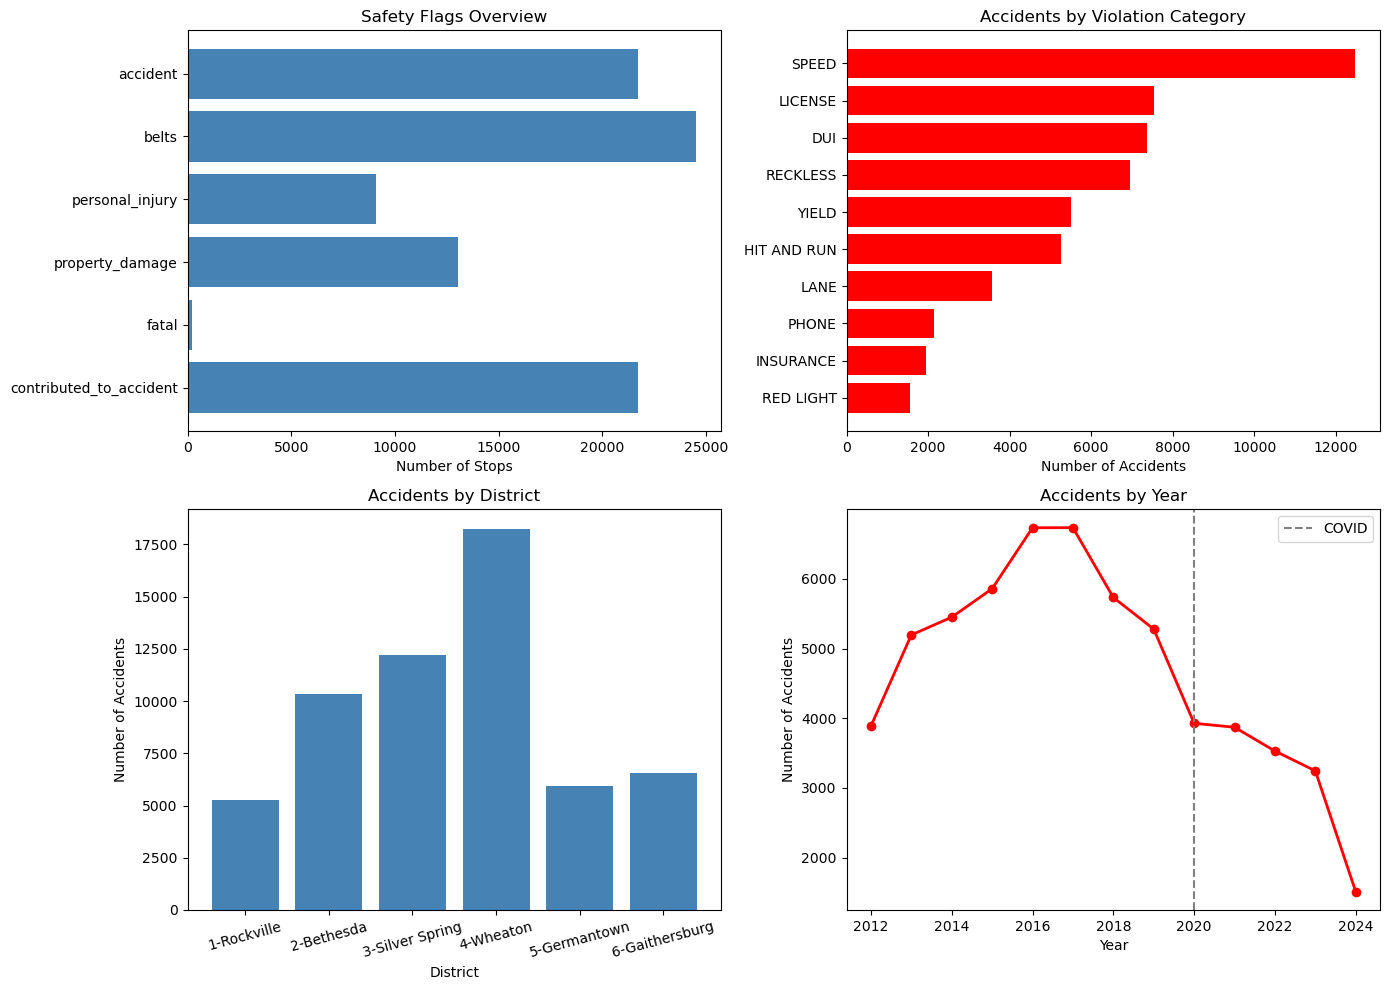

In [ ]:
# ============================================================
# SAFETY ANALYSIS - QUICK PLOTS
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Safety flag overview
safety_cols = ['accident', 'belts', 'personal_injury',
               'property_damage', 'fatal', 'contributed_to_accident']
safety_counts = [incident_safety_df[col].sum() for col in safety_cols]
axes[0,0].barh(safety_cols[::-1], safety_counts[::-1], color='steelblue')
axes[0,0].set_title('Safety Flags Overview')
axes[0,0].set_xlabel('Number of Stops')

# 2. Accidents by violation category
acc_violations = safety_analysis[
    safety_analysis['accident'] == 1
]['violation_category'].value_counts().head(10)
axes[0,1].barh(acc_violations.index[::-1], acc_violations.values[::-1], color='red')
axes[0,1].set_title('Accidents by Violation Category')
axes[0,1].set_xlabel('Number of Accidents')

# 3. Accidents by district
dist_accidents = safety_analysis[
    safety_analysis['accident'] == 1
]['district_number'].value_counts().sort_index()
dist_labels = [
    '1-Rockville', '2-Bethesda', '3-Silver Spring',
    '4-Wheaton', '5-Germantown', '6-Gaithersburg'
]
axes[1,0].bar(dist_labels, dist_accidents.values, color='steelblue')
axes[1,0].set_title('Accidents by District')
axes[1,0].set_xlabel('District')
axes[1,0].set_ylabel('Number of Accidents')
axes[1,0].tick_params(axis='x', rotation=15)

# 4. Accidents by year
acc_year = safety_analysis[
    safety_analysis['accident'] == 1
]['year'].value_counts().sort_index()
acc_year = acc_year[acc_year.index <= 2024]
axes[1,1].plot(acc_year.index, acc_year.values,
               color='red', marker='o', linewidth=2)
axes[1,1].set_title('Accidents by Year')
axes[1,1].set_xlabel('Year')
axes[1,1].set_ylabel('Number of Accidents')
axes[1,1].axvline(x=2020, color='gray', linestyle='--', label='COVID')
axes[1,1].legend()

plt.tight_layout()
plt.savefig('../images/safety_analysis.png', dpi=100, bbox_inches='tight')
plt.show()

## SEARCH & ENFORCEMENT ANALYSIS

In [24]:
# ============================================================
# SEARCH & ENFORCEMENT ANALYSIS
# ============================================================

# Overall metrics
total_stops = search_enforcement_df['stop_id'].nunique()
searches    = (search_enforcement_df['search_conducted'] == 1).sum()
arrests     = (search_enforcement_df['search_outcome'] == 'Arrest').sum()

print("=" * 50)
print("OVERALL METRICS")
print("=" * 50)
print(f"Total stops:         {total_stops:,}")
print(f"Searches conducted:  {searches:,} ({searches/total_stops*100:.1f}%)")
print(f"Arrests:             {arrests:,} ({arrests/total_stops*100:.1f}%)")

# Contraband hit rate
searched = search_enforcement_df[search_enforcement_df['search_conducted'] == 1]
contraband = searched[
    searched['search_disposition'].str.contains('Contraband', na=False)
].shape[0]
print(f"Contraband hit rate: {contraband/searches*100:.1f}%")

# Search reason vs outcome
print("\nSearch outcome by reason:")
reason_outcome = search_enforcement_df[
    search_enforcement_df['search_reason'] != 'Not Applicable'
].groupby(['search_reason', 'search_outcome']).size().unstack(fill_value=0)
print(reason_outcome)

# Search disposition by type
print("\nSearch disposition by type:")
disp_type = search_enforcement_df[
    search_enforcement_df['search_type'] != 'NOT APPLICABLE'
].groupby(['search_type', 'search_disposition']).size().unstack(fill_value=0)
print(disp_type)

# Arrest type breakdown
print("\nArrest type breakdown:")
print(search_enforcement_df['arrest_type_desc'].value_counts().head(10))

# Search rate by district
search_district = search_enforcement_df.merge(
    traffic_stop_df[['stop_id', 'district_number']], on='stop_id'
)
print("\nSearch rate by district:")
print(search_district.groupby('district_number')['search_conducted']
      .mean().sort_values(ascending=False).round(3) * 100)

OVERALL METRICS
Total stops:         568,317
Searches conducted:  69,983 (12.3%)
Arrests:             53,537 (9.4%)
Contraband hit rate: 36.7%

Search outcome by reason:
search_outcome         Arrest  Citation  Recovered Evidence  SERO  Warning
search_reason                                                             
Consensual               1893      5495                   0    19      387
Exigent Circumstances     332       114                   0     0        6
Incident to Arrest      42486      4341                   3    19       88
K-9                       404       556                   0     1       52
Other                     423       495                   0     5       10
Plain View                  0         1                   0     0        0
Probable Cause           7475      5164                   0    10      204

Search disposition by type:
search_disposition  Contraband Only  Contraband and Property  DUI  \
search_type                                              

```a
Search reasons → outcomes:
Incident to Arrest  → 90.6% lead to arrest (42,486)
Exigent Circumstances → 73.5% arrest rate
Probable Cause      → 58.2% arrest rate
K-9                 → 39.9% arrest rate
Consensual          → 24.3% arrest rate ← lowest

Search type → contraband:
BOTH        → 47.9% find contraband
PROPERTY    → 30.1% find contraband
PERSON      → 16.5% find contraband

Search rate by district:
District 3 (Silver Spring)  10.0%  → highest
District 4 (Wheaton)         7.8%
District 2 (Bethesda)        4.0%  → lowest

Arrest types:
Marked Patrol    785,542  (74.9%)
Marked Laser     127,824  (12.2%)
Unmarked Patrol   55,943   (5.3%)

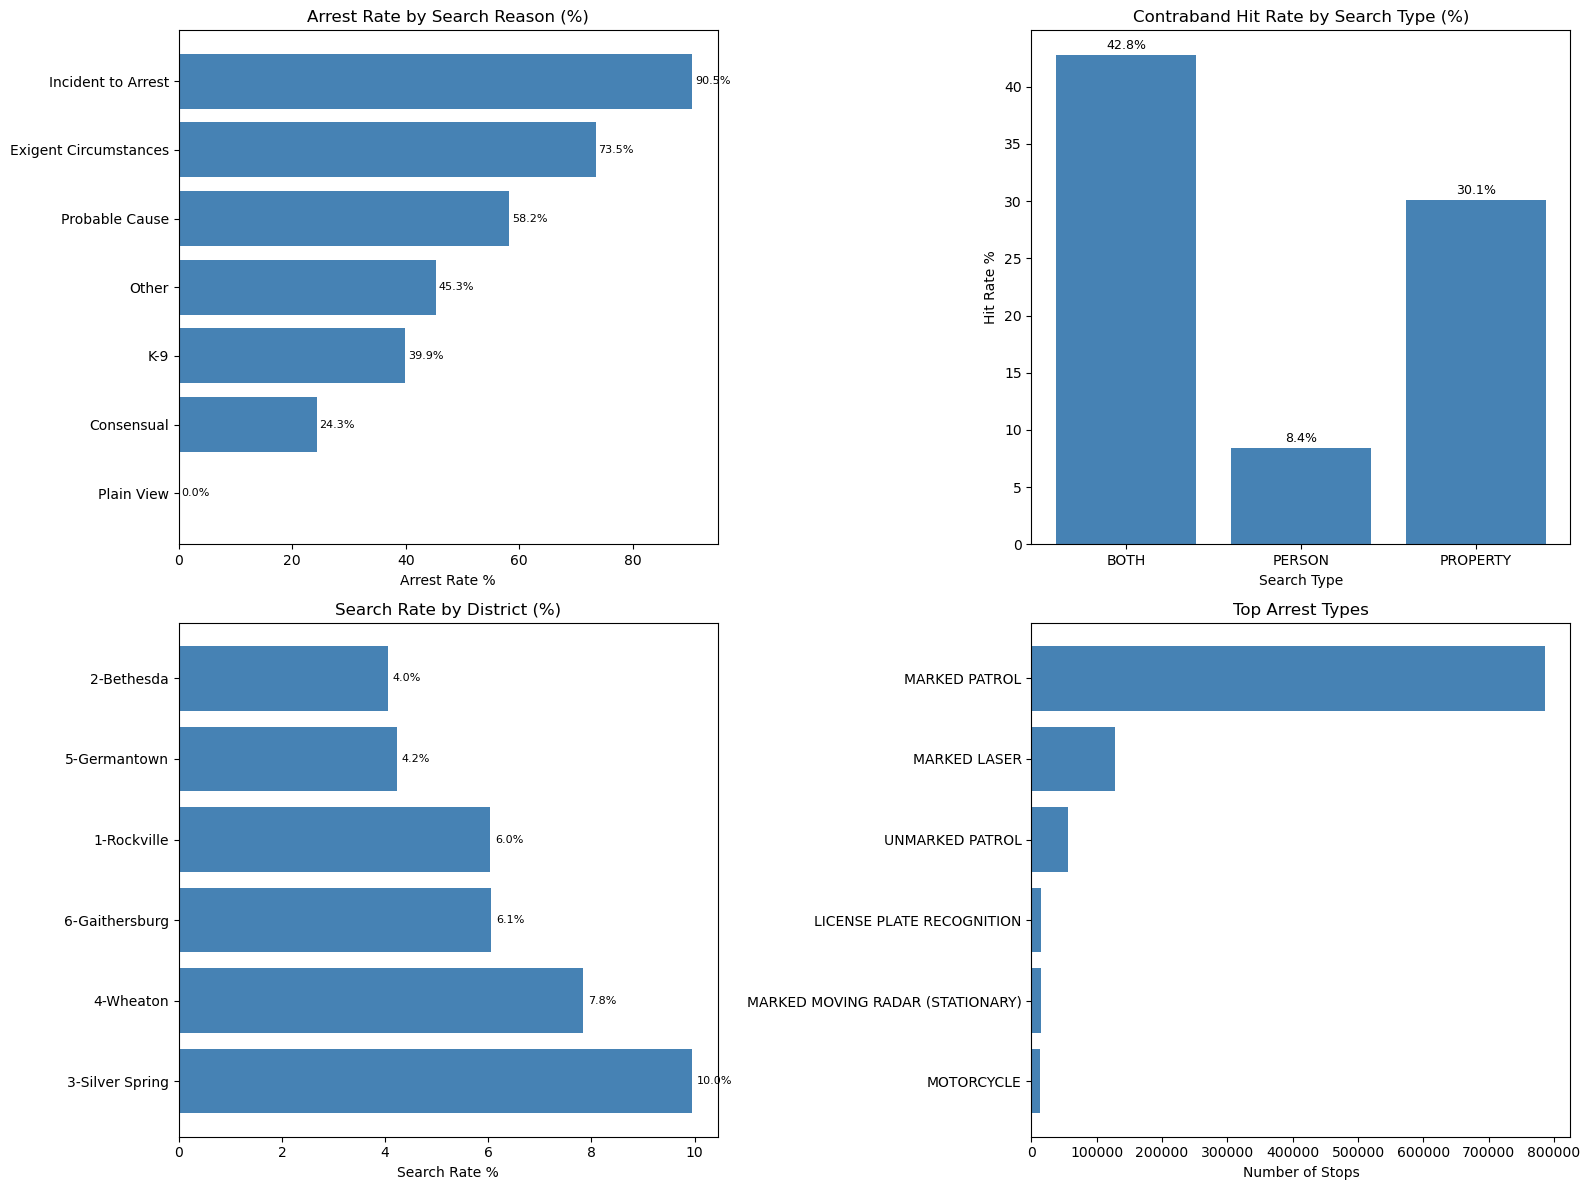

In [ ]:
# ============================================================
# SEARCH & ENFORCEMENT - QUICK PLOTS
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Search reason vs arrest rate
reason_arrest = search_enforcement_df[
    search_enforcement_df['search_reason'] != 'Not Applicable'
].groupby('search_reason').agg(
    total=('stop_id', 'count'),
    arrests=('search_outcome', lambda x: (x == 'Arrest').sum())
).reset_index()
reason_arrest['arrest_rate'] = (
    reason_arrest['arrests'] / reason_arrest['total'] * 100
).round(1)
reason_arrest = reason_arrest.sort_values('arrest_rate')

axes[0,0].barh(reason_arrest['search_reason'], 
               reason_arrest['arrest_rate'], color='steelblue')
axes[0,0].set_title('Arrest Rate by Search Reason (%)')
axes[0,0].set_xlabel('Arrest Rate %')
for i, v in enumerate(reason_arrest['arrest_rate']):
    axes[0,0].text(v + 0.5, i, f'{v}%', va='center', fontsize=8)

# 2. Contraband hit rate by search type
type_contraband = search_enforcement_df[
    ~search_enforcement_df['search_type'].isin(
        ['NOT APPLICABLE', 'INCIDENT TO ARREST', 'PROBABLE CAUSE'])
].groupby('search_type').agg(
    total=('stop_id', 'count'),
    contraband=('search_disposition', 
                lambda x: x.str.contains('Contraband', na=False).sum())
).reset_index()
type_contraband['hit_rate'] = (
    type_contraband['contraband'] / type_contraband['total'] * 100
).round(1)

axes[0,1].bar(type_contraband['search_type'], 
              type_contraband['hit_rate'], color='steelblue')
axes[0,1].set_title('Contraband Hit Rate by Search Type (%)')
axes[0,1].set_xlabel('Search Type')
axes[0,1].set_ylabel('Hit Rate %')
for i, v in enumerate(type_contraband['hit_rate']):
    axes[0,1].text(i, v + 0.5, f'{v}%', ha='center', fontsize=9)

# 3. Search rate by district
search_by_district = search_district.groupby('district_number')[
    'search_conducted'].mean().sort_values(ascending=False) * 100
dist_labels = {
    1.0: '1-Rockville', 2.0: '2-Bethesda', 
    3.0: '3-Silver Spring', 4.0: '4-Wheaton',
    5.0: '5-Germantown', 6.0: '6-Gaithersburg'
}
search_by_district.index = search_by_district.index.map(dist_labels)
axes[1,0].barh(search_by_district.index, 
               search_by_district.values, color='steelblue')
axes[1,0].set_title('Search Rate by District (%)')
axes[1,0].set_xlabel('Search Rate %')
for i, v in enumerate(search_by_district.values):
    axes[1,0].text(v + 0.1, i, f'{v:.1f}%', va='center', fontsize=8)

# 4. Arrest type breakdown
top_arrest_types = search_enforcement_df[
    'arrest_type_desc'].value_counts().head(6)
axes[1,1].barh(top_arrest_types.index[::-1], 
               top_arrest_types.values[::-1], color='steelblue')
axes[1,1].set_title('Top Arrest Types')
axes[1,1].set_xlabel('Number of Stops')

plt.tight_layout()
plt.savefig('../images/search_enforcement_analysis.png', dpi=100, bbox_inches='tight')
plt.show()

## CROSS FEATURE ANALYSIS

In [26]:
# ============================================================
# CROSS FEATURE ANALYSIS - COMPLETE
# ============================================================

import pandas as pd

# Step 1 — Build stop-level cross df
top_violation_per_stop = violation_charge_df.groupby('stop_id').agg(
    violation_category=('violation_category', lambda x: x.value_counts().index[0]),
    violation_type    =('violation_type',     lambda x: x.value_counts().index[0])
).reset_index()

cross_df = (
    traffic_stop_df[['stop_id', 'district_number', 'stop_timestamp', 'year']]
    .merge(
        driver_vehicle_df[['stop_id', 'race', 'gender', 'make', 'year']],
        on='stop_id', suffixes=('_stop', '_vehicle')
    )
    .merge(top_violation_per_stop, on='stop_id')
    .merge(
        search_enforcement_df[['stop_id', 'search_conducted',
                               'search_disposition', 'arrest_type_desc']]
        .drop_duplicates('stop_id'), on='stop_id'
    )
    .merge(
        incident_safety_df[['stop_id', 'accident', 'fatal']]
        .drop_duplicates('stop_id'), on='stop_id'
    )
)

# Extract hour
cross_df['hour'] = pd.to_datetime(cross_df['stop_timestamp']).dt.hour

print(f"Shape: {cross_df.shape}")
print(f"Unique stops: {cross_df['stop_id'].nunique():,}")

# ── 1. Top violation by race ──────────────────────────────
print("\n1. Top violation by race:")
print(cross_df.groupby('race')['violation_category']
      .agg(lambda x: x.value_counts().index[0]))

# ── 2. Search rate by violation category ─────────────────
print("\n2. Search rate by violation category:")
search_by_violation = cross_df.groupby('violation_category').agg(
    total   =('stop_id', 'count'),
    searches=('search_conducted', 'sum')
).reset_index()
search_by_violation['search_rate'] = (
    search_by_violation['searches'] /
    search_by_violation['total'] * 100
).round(1)
print(search_by_violation.sort_values(
    'search_rate', ascending=False).to_string())

# ── 3. Fatal accidents by violation ──────────────────────
print("\n3. Fatal accidents by violation:")
print(cross_df[cross_df['fatal'] == 1]['violation_category']
      .value_counts().head(10))

# ── 4. Citation rate by district ─────────────────────────
print("\n4. Citation rate by district:")
dist_citation = cross_df.groupby('district_number').agg(
    total    =('stop_id', 'count'),
    citations=('violation_type', lambda x: (x == 'CITATION').sum())
).reset_index()
dist_citation['citation_rate'] = (
    dist_citation['citations'] /
    dist_citation['total'] * 100
).round(1)
dist_citation['district_name'] = dist_citation['district_number'].map({
    1.0: '1-Rockville', 2.0: '2-Bethesda',
    3.0: '3-Silver Spring', 4.0: '4-Wheaton',
    5.0: '5-Germantown', 6.0: '6-Gaithersburg'
})
print(dist_citation.sort_values('citation_rate', ascending=False).to_string())

# ── 5. Accident rate by top 10 makes ─────────────────────
print("\n5. Accident rate by top 10 makes:")
make_accident = cross_df.groupby('make').agg(
    total    =('stop_id', 'count'),
    accidents=('accident', 'sum')
).reset_index()
make_accident['accident_rate'] = (
    make_accident['accidents'] /
    make_accident['total'] * 100
).round(1)
top_makes = driver_vehicle_df['make'].value_counts().head(10).index
print(make_accident[make_accident['make'].isin(top_makes)]
      .sort_values('accident_rate', ascending=False).to_string())

# ── 6. Search rate by race + gender ──────────────────────
print("\n6. Search rate by race and gender:")
print((cross_df.groupby(['race', 'gender'])['search_conducted']
      .mean() * 100).round(1))

# ── 7. Top violation by hour ──────────────────────────────
print("\n7. Top violation by hour:")
print(cross_df.groupby('hour')['violation_category']
      .agg(lambda x: x.value_counts().index[0]))

Shape: (568317, 16)
Unique stops: 568,317

1. Top violation by race:
race
ASIAN              SPEED
BLACK              SPEED
HISPANIC           SPEED
NATIVE AMERICAN    PHONE
OTHER              SPEED
WHITE              SPEED
Name: violation_category, dtype: object

2. Search rate by violation category:
   violation_category   total  searches  search_rate
0                 DUI   21520      5504         25.6
13           RECKLESS    6558       548          8.4
8             LICENSE   90408      4783          5.3
4         HIT AND RUN    3459       105          3.0
15       REGISTRATION   38929      1145          2.9
6           INSURANCE    4392       119          2.7
7                LANE   15984       323          2.0
1           EQUIPMENT   30692       503          1.6
3               FRAUD   15051       241          1.6
5       IMPROPER TURN    6555        90          1.4
11            PARKING    4543        54          1.2
14          RED LIGHT   12237       117          1.0
2       

- 1. Top violation by race:

```a
SPEED dominates for all races
PHONE for NATIVE AMERICAN — interesting outlier

2. Search rate by violation:

```a
DUI          25.6%  → highest search rate ✅ makes sense
RECKLESS      8.4%  → second
LICENSE       5.3%  → third
SPEED         0.3%  → lowest — rarely searched
PHONE         0.5%  → rarely searched

3. Fatal accidents:

```a
SPEED    68  → deadliest violation
YIELD    29  → second
RECKLESS 24  → third

4. Citation rate by district 

```a
District 3 Silver Spring  85.9%  → strictest
District 4 Wheaton        80.7%
District 2 Bethesda       80.3%
District 1 Rockville      72.9%
District 6 Gaithersburg   72.4%
District 5 Germantown     65.3%  → most lenient

5. Search rate by violation category:

```a
DUI          25.6%  → highest — officers always search DUI stops
RECKLESS      8.4%  → second — dangerous driving = closer inspection
LICENSE       5.3%  → third — suspended drivers often searched
SPEED         0.3%  → lowest — routine stops, rarely searched
PHONE         0.5%  → routine stop, rarely searched

Story: 
The more dangerous the violation, the higher the search rate. DUI is 85x more likely to trigger a search than speeding!

6. Search rate by race and gender:

```a
BLACK Male      5.0%  → highest search rate
HISPANIC Male   4.4%  → second
WHITE Male      2.1%  → less than half Black male rate
BLACK Female    1.7%  → higher than White male (2.1%? no)
ASIAN Male      1.7%  → lowest male rate
All Females     0.6-1.8% → consistently lower than males

Gender gap:  Males searched 2-3x more than females
Race gap:    Black/Hispanic males searched 
             2x more than White males
Most searched:  
Black Male (5.0%)
Least searched: 
Asian Female (0.6%)

7. Top violation by hour:

```a
12am - 1am  → LICENSE   drivers out late with suspended license
2am  - 4am  → DUI       bar closing time — drunk driving peak!
5am  - 3pm  → SPEED     morning/afternoon commute
4pm  - 5pm  → PHONE     evening commute — distracted driving
6pm  - 11pm → LICENSE   evening suspended drivers

Clear pattern emerges:
Night (2-4am)    → most dangerous (DUI)
Morning (5-3pm)  → speed enforcement
Evening (4-5pm)  → phone enforcement
Late night       → license enforcement

8. Fatal accidents by violation:


```a
SPEED    68  → deadliest — high impact crashes
YIELD    29  → failure to yield = collision risk
RECKLESS 24  → dangerous driving behavior
LICENSE  20  → unlicensed = less skilled drivers
PHONE    16  → distracted driving deaths

Story: 
Speed kills — responsible for nearly double the fatalities of the next closest violation. 
Combined SPEED + RECKLESS = 92 fatalities which represents dangerous driving behavior.

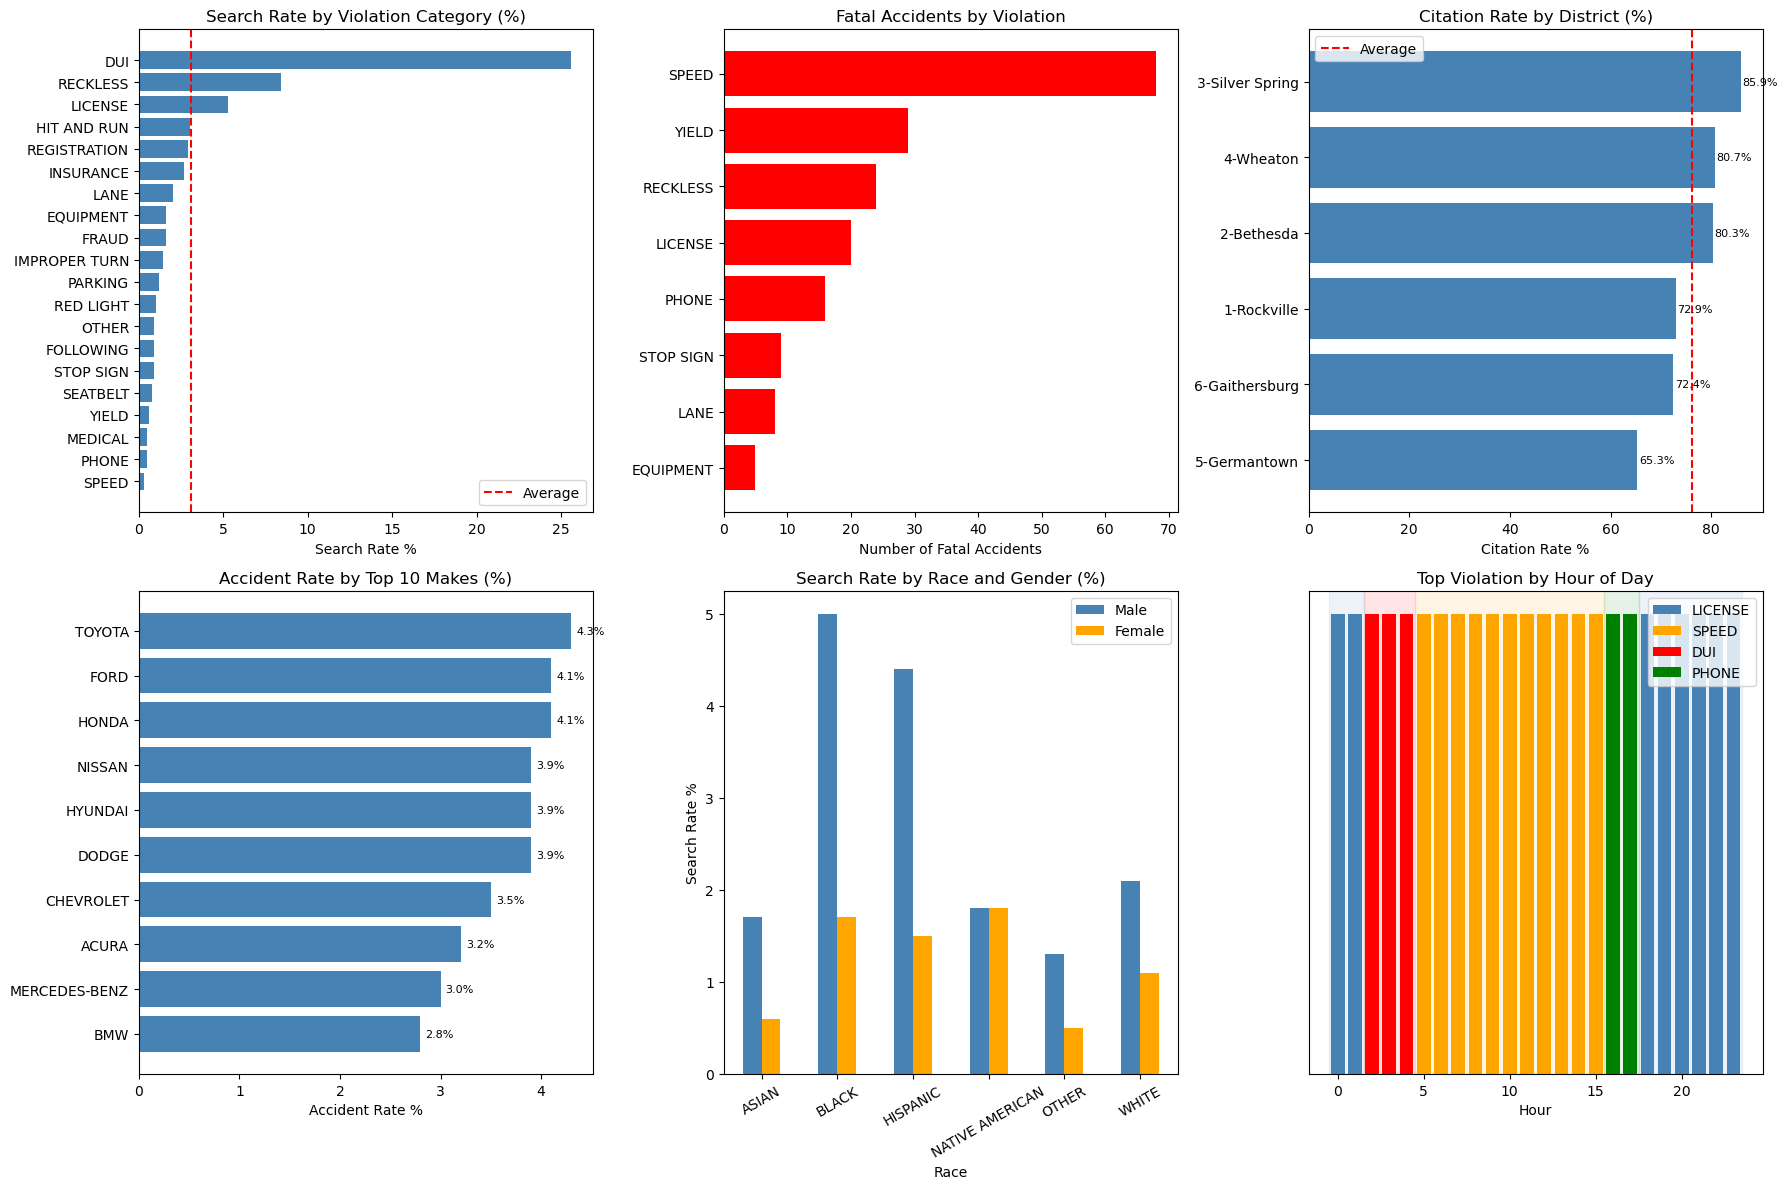

In [ ]:
# ============================================================
# CROSS FEATURE ANALYSIS - PLOTS
# ============================================================

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# 1. Search rate by violation category
search_by_violation_sorted = search_by_violation.sort_values('search_rate')
axes[0,0].barh(search_by_violation_sorted['violation_category'],
               search_by_violation_sorted['search_rate'], color='steelblue')
axes[0,0].set_title('Search Rate by Violation Category (%)')
axes[0,0].set_xlabel('Search Rate %')
axes[0,0].axvline(x=search_by_violation['search_rate'].mean(),
                  color='red', linestyle='--', label='Average')
axes[0,0].legend()

# 2. Fatal accidents by violation
fatal_violations = cross_df[cross_df['fatal'] == 1]['violation_category'].value_counts().head(8)
axes[0,1].barh(fatal_violations.index[::-1], fatal_violations.values[::-1], color='red')
axes[0,1].set_title('Fatal Accidents by Violation')
axes[0,1].set_xlabel('Number of Fatal Accidents')

# 3. Citation rate by district
dist_citation_sorted = dist_citation.sort_values('citation_rate', ascending=True)
axes[0,2].barh(dist_citation_sorted['district_name'],
               dist_citation_sorted['citation_rate'], color='steelblue')
axes[0,2].set_title('Citation Rate by District (%)')
axes[0,2].set_xlabel('Citation Rate %')
axes[0,2].axvline(x=dist_citation['citation_rate'].mean(),
                  color='red', linestyle='--', label='Average')
axes[0,2].legend()
for i, v in enumerate(dist_citation_sorted['citation_rate']):
    axes[0,2].text(v + 0.3, i, f'{v}%', va='center', fontsize=8)

# 4. Accident rate by top 10 makes
make_acc_sorted = make_accident[
    make_accident['make'].isin(top_makes)
].sort_values('accident_rate')
axes[1,0].barh(make_acc_sorted['make'],
               make_acc_sorted['accident_rate'], color='steelblue')
axes[1,0].set_title('Accident Rate by Top 10 Makes (%)')
axes[1,0].set_xlabel('Accident Rate %')
for i, v in enumerate(make_acc_sorted['accident_rate']):
    axes[1,0].text(v + 0.05, i, f'{v}%', va='center', fontsize=8)

# 5. Search rate by race and gender
search_race_gender = (cross_df.groupby(['race', 'gender'])['search_conducted']
                      .mean() * 100).round(1).unstack()
search_race_gender = search_race_gender[['M', 'F']]
search_race_gender.plot(kind='bar', ax=axes[1,1], color=['steelblue', 'orange'])
axes[1,1].set_title('Search Rate by Race and Gender (%)')
axes[1,1].set_xlabel('Race')
axes[1,1].set_ylabel('Search Rate %')
axes[1,1].tick_params(axis='x', rotation=30)
axes[1,1].legend(['Male', 'Female'])

# 6. Top violation by hour
hour_violation = cross_df.groupby('hour')['violation_category'].agg(
    lambda x: x.value_counts().index[0])
color_map = {
    'LICENSE' : 'steelblue',
    'SPEED'   : 'orange',
    'DUI'     : 'red',
    'PHONE'   : 'green',
}
colors = [color_map.get(v, 'gray') for v in hour_violation.values]
axes[1,2].bar(hour_violation.index, 1, color=colors)
axes[1,2].set_title('Top Violation by Hour of Day')
axes[1,2].set_xlabel('Hour')
axes[1,2].set_yticks([])

# Add legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='steelblue', label='LICENSE'),
    Patch(facecolor='orange',    label='SPEED'),
    Patch(facecolor='red',       label='DUI'),
    Patch(facecolor='green',     label='PHONE'),
]
axes[1,2].legend(handles=legend_elements, loc='upper right')

# Annotate time periods
axes[1,2].axvspan(-0.5, 1.5,  alpha=0.1, color='steelblue')
axes[1,2].axvspan(1.5,  4.5,  alpha=0.1, color='red')
axes[1,2].axvspan(4.5,  15.5, alpha=0.1, color='orange')
axes[1,2].axvspan(15.5, 17.5, alpha=0.1, color='green')
axes[1,2].axvspan(17.5, 23.5, alpha=0.1, color='steelblue')

plt.tight_layout()
plt.savefig('../images/cross_feature_analysis.png', dpi=100, bbox_inches='tight')
plt.show()

In [28]:
# ============================================================
# EDA COMPLETE SUMMARY
# ============================================================

print("=" * 60)
print("       MONTGOMERY COUNTY TRAFFIC STOPS - EDA SUMMARY")
print("=" * 60)

print("\n📅 TEMPORAL ANALYSIS")
print("-" * 60)
print(f"  Date range:          2012 → 2025")
print(f"  Total stops:         {568317:,}")
print(f"  Peak year:           2014 ({71617:,} stops)")
print(f"  COVID drop:          2020 ({16152:,} stops → lowest)")
print(f"  Busiest day:         Tuesday ({95613:,} stops)")
print(f"  Quietest day:        Sunday ({58720:,} stops)")
print(f"  Morning peak:        8am ({47378:,} stops)")
print(f"  Evening peak:        4pm ({31822:,} stops)")
print(f"  Quietest hour:       4am ({4763:,} stops)")

print("\n⚖️ VIOLATION ANALYSIS")
print("-" * 60)
print(f"  Top violation:       LICENSE ({243918:,} charges)")
print(f"  Second:              SPEED ({210315:,} charges)")
print(f"  Third:               PHONE ({110871:,} charges)")
print(f"  Citation rate:       81.8% overall")
print(f"  Strictest:           DUI (99.9% citation rate)")
print(f"  Most lenient:        EQUIPMENT (65.2% citation rate)")
print(f"  Most fatal:          SPEED (68 fatal accidents)")

print("\n🌆 GEOGRAPHIC ANALYSIS")
print("-" * 60)
print(f"  Busiest district:    District 2 Bethesda ({104907:,})")
print(f"  Quietest district:   District 6 Gaithersburg ({64099:,})")
print(f"  Strictest district:  District 3 Silver Spring (85.9% citation)")
print(f"  Most lenient:        District 5 Germantown (65.3% citation)")
print(f"  Top hotspot:         IS 370/IS 270 ({1703:,} stops)")
print(f"  Most stops at:       Intersections (88.2%)")

print("\n🚙 VEHICLE ANALYSIS")
print("-" * 60)
print(f"  Most stopped make:   TOYOTA ({101559:,})")
print(f"  Most stopped model:  SEDAN ({100032:,})")
print(f"  Most stopped color:  BLACK ({117947:,})")
print(f"  Avg vehicle age:     8.3 years at time of stop")
print(f"  Most common type:    AUTOMOBILE (83.4%)")
print(f"  Highest accident rate: TOYOTA (4.0%)")
print(f"  Lowest accident rate:  BMW (2.6%)")

print("\n🔍 SEARCH & ENFORCEMENT ANALYSIS")
print("-" * 60)
print(f"  Search rate:         12.3% ({69983:,} searches)")
print(f"  Contraband hit rate: 36.7%")
print(f"  Arrest rate:         9.4% ({53537:,} arrests)")
print(f"  Top search reason:   Incident to Arrest (67.1%)")
print(f"  Most common type:    BOTH - person+vehicle (74.8%)")
print(f"  Highest search rate: District 3 (10.0%)")
print(f"  Lowest search rate:  District 2 (4.0%)")
print(f"  DUI search rate:     25.6% — 85x higher than SPEED")

print("\n🛡️ SAFETY & ACCIDENT ANALYSIS")
print("-" * 60)
print(f"  Total accidents:     {50333:,} (4.8% of stops)")
print(f"  Fatal accidents:     {401:,} (0.04%)")
print(f"  Personal injuries:   {22599:,} (2.16%)")
print(f"  Property damage:     {39306:,} (3.75%)")
print(f"  Seatbelt violations: {40579:,} (3.87%)")
print(f"  Belt + accident:     {5045:,} (12.4% of belt violations)")
print(f"  Most dangerous:      DUI → most accidents")
print(f"  Deadliest:           SPEED → 68 fatal accidents")

print("\n👤 DEMOGRAPHIC ANALYSIS")
print("-" * 60)
print(f"  Most stopped race:   WHITE ({220031:,})")
print(f"  Most stopped gender: MALE ({367583:,})")
print(f"  Highest search rate:Black male drivers had the highest observed search rate (5.0%) in the dataset (based on recorded traffic stop data..)")
print(f"  Lowest search rate:  ASIAN Female (0.6%)")
print(f"  Highest arrest rate: HISPANIC (7.4%)")
print(f"  Lowest arrest rate:  OTHER (2.1%)")
print(f"  Male search rate:    8.0% vs Female 3.6%")
print(f"  Male arrest rate:    6.1% vs Female 2.9%")

print("\n🔗 CROSS FEATURE INSIGHTS")
print("-" * 60)
print(f"  Top violation all races:  SPEED (except NATIVE AMERICAN→PHONE)")
print(f"  DUI search rate:          25.6% — highest by far")
print(f"  Fatal violations:         SPEED(68) > YIELD(29) > RECKLESS(24)")
print(f"  Strictest district:       District 3 Silver Spring (85.9%)")
print(f"  Most searched:            Black Male (5.0%)")
print(f"  Least searched:           Asian Female (0.6%)")
print(f"  DUI peak hours:           2am-4am (bar closing time)")
print(f"  SPEED peak hours:         5am-3pm (commute hours)")
print(f"  PHONE peak hours:         4pm-5pm (evening commute)")
print(f"  LICENSE peak hours:       6pm-midnight")

print("\n" + "=" * 60)
print("  EDA COMPLETE ")
print("=" * 60)

       MONTGOMERY COUNTY TRAFFIC STOPS - EDA SUMMARY

📅 TEMPORAL ANALYSIS
------------------------------------------------------------
  Date range:          2012 → 2025
  Total stops:         568,317
  Peak year:           2014 (71,617 stops)
  COVID drop:          2020 (16,152 stops → lowest)
  Busiest day:         Tuesday (95,613 stops)
  Quietest day:        Sunday (58,720 stops)
  Morning peak:        8am (47,378 stops)
  Evening peak:        4pm (31,822 stops)
  Quietest hour:       4am (4,763 stops)

⚖️ VIOLATION ANALYSIS
------------------------------------------------------------
  Top violation:       LICENSE (243,918 charges)
  Second:              SPEED (210,315 charges)
  Third:               PHONE (110,871 charges)
  Citation rate:       81.8% overall
  Strictest:           DUI (99.9% citation rate)
  Most lenient:        EQUIPMENT (65.2% citation rate)
  Most fatal:          SPEED (68 fatal accidents)

🌆 GEOGRAPHIC ANALYSIS
-----------------------------------------------